In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
train_digits = []
with open('/content/drive/MyDrive/Courses/2023 Fall CMPE 257/Colab/digits/ZipDigits.train') as fp:
    for line in fp:
        train_digits.append([float(x) for x in line.split()])

train_digits = np.array(train_digits)


In [16]:
train_digits.shape

(7291, 257)

In [17]:
def print_digit(digit_row):
    digit_row = digit_row[1:257]
    digit_row = digit_row.reshape(16, 16)
    digit_row = (digit_row + 1)/2
    plt.imshow(digit_row, cmap='gray', vmin=0, vmax=1)


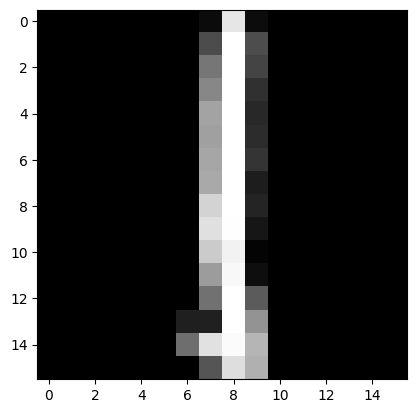

In [20]:
print_digit(train_digits[9])

My Helper Functions

In [21]:
def extract_features(digit_row):
    intensity = np.sum((digit_row + 1)/2)/256
    digit_row = digit_row[1:257]
    digit_row = digit_row.reshape(16, 16)
    flipped_hor = np.flip(digit_row, 1)
    flipped_ver = np.flip(digit_row, 0)
    hor_symmetry = np.sum(np.multiply(digit_row, flipped_hor))/256
    ver_symmetry = np.sum(np.multiply(digit_row, flipped_ver))/256
    symmetry = (hor_symmetry + ver_symmetry)/2
    return intensity, symmetry

In [22]:
def plot_features(X, y):
    colors = []
    for y_col in y:
        if y_col == 1:
            colors.append('b')
        else:
            colors.append('r')
    plt.scatter(X[:,0], X[:,1], color=colors)

def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept) )

In [23]:
digit1 = 1
digit2 = 5
train_digits = train_digits[(train_digits[:,0] == digit1) | (train_digits[:,0] == digit2)]

In [24]:
X = []
y = []
for row in train_digits:
    intensity, symmetry = extract_features(row)
    X.append([intensity, symmetry])
    if row[0] == digit1:
        y.append(1)
    else:
        y.append(-1)

X = np.array(X)
y = np.array(y)


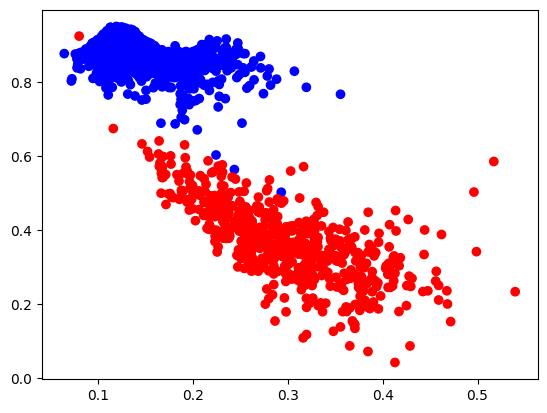

In [25]:
plot_features(X, y)